In [1]:
import os
os.chdir('/home/bjaha/Documents/RL-catalyst/nat-com-test')


from src.data.reference_dataloader import (
    ReferenceDataFinder,
    ReferenceDataLoader
)
from src.performance.energetics import EnergyUnit

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:

data_dir='data'

finder = ReferenceDataFinder(data_dir=data_dir)
loader = ReferenceDataLoader(data_dir=data_dir)
good_datasets = finder.get_good_datasets()
print(good_datasets)


['qm9', 'qm7']


In [3]:
dataset = 'qm9'
ref_data = loader.load_and_polish(
    mol_dataset=dataset, 
    new_energy_unit=EnergyUnit.EV, 
    fetch_df=True
)

ref_data.df.head()

,atomic_symbols,atomic_nums,pos,elements_unique,symbols_sorted,bag_repr,n_atoms,energy_GFN2,SMILES,smiles,formulas,con_mat
0,"[C, H, H, H, H]","[6, 1, 1, 1, 1]","[[-0.0126981359, 1.0858041578, 0.0080009958], ...","[1, 6]","[H, C]",H4C,5,-113.606848,C,[H]C([H])([H])[H],"((1, 4), (6, 1))","[[0, 1, 1, 1, 1], [1, 0, 0, 0, 0], [1, 0, 0, 0..."
1,"[N, H, H, H]","[7, 1, 1, 1]","[[-0.0404260543, 1.0241077531, 0.0625637998], ...","[1, 7]","[H, N]",H3N,4,-120.435521,N,[H]N([H])[H],"((1, 3), (7, 1))","[[0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 0], [1,..."
2,"[O, H, H]","[8, 1, 1]","[[-0.0343604951, 0.9775395708, 0.0076015923], ...","[1, 8]","[H, O]",H2O,3,-137.969344,O,[H]O[H],"((1, 2), (8, 1))","[[0, 1, 1], [1, 0, 0], [1, 0, 0]]"
3,"[C, C, H, H]","[6, 6, 1, 1]","[[0.5995394918, 0.0, 1.0], [-0.5995394918, 0.0...","[1, 6]","[H, C]",H2C2,4,-141.675936,C#C,[H]C#C[H],"((1, 2), (6, 2))","[[0, 3, 0, 1], [3, 0, 1, 0], [0, 1, 0, 0], [1,..."
4,"[C, N, H]","[6, 7, 1]","[[-0.0133239314, 1.1324657151, 0.0082758861], ...","[1, 6, 7]","[H, C, N]",HCN,3,-149.758939,C#N,[H]C#N,"((1, 1), (6, 1), (7, 1))","[[0, 3, 1], [3, 0, 0], [1, 0, 0]]"


In [4]:
from ase import Atom, Atoms
from ase.visualize import view
from xtb.ase.calculator import XTB

import numpy as np


obs = ref_data.df.iloc[450]

atoms = Atoms(
symbols=obs.atomic_symbols,
positions=obs.pos
)
view(atoms)


<Popen: returncode: None args: ['/home/bjaha/.local/share/mamba/envs/net-com...>

Dipole moment 440: 0.8594918508699391 Debye
Dipole moment 441: 1.0391247708084934 Debye
Dipole moment 442: 0.7097797753483941 Debye
Dipole moment 443: 0.9486550626590153 Debye
Dipole moment 444: 0.39533585056538406 Debye
Dipole moment 445: 0.44152716696256816 Debye
Dipole moment 446: 0.9210570859702837 Debye
Dipole moment 447: 1.029136363040328 Debye
Dipole moment 448: 0.6799301462759761 Debye
Dipole moment 449: 0.6304896692758869 Debye
Dipole moment 450: 1.1957450223678838 Debye
Dipole moment 451: 0.9715091395275991 Debye
Dipole moment 452: 1.1763296364960671 Debye
Dipole moment 453: 0.4366683505690934 Debye
Dipole moment 454: 0.08200350517870796 Debye
Dipole moment 455: 0.08822850931325704 Debye
Dipole moment 456: 0.270248067227621 Debye
Dipole moment 457: 0.36857885666690815 Debye
Dipole moment 458: 0.06763716046741752 Debye
Dipole moment 459: 0.37820361526453583 Debye
Dipole moment 460: 0.4370853086740535 Debye
Dipole moment 461: 0.3301375457028407 Debye
Dipole moment 462: 0.456981

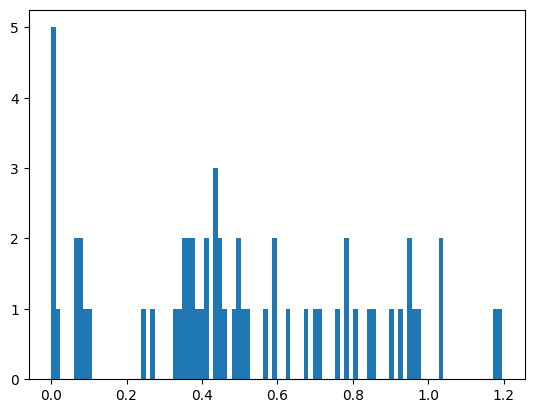

In [ ]:
# transform arbitrary mol into ase atoms object


from ase import Atom, Atoms
from ase.visualize import view
from xtb.ase.calculator import XTB

import numpy as np

dipoles = []
for i in range(440, 500):
    obs = ref_data.df.iloc[i]

    atoms = Atoms(
    symbols=obs.atomic_symbols,
    positions=obs.pos
    )
    # view(atoms)

    calc = XTB()
    calc.calculate(atoms=atoms)
    dipole_moment = calc.results["dipole"]
    dipole = np.linalg.norm(dipole_moment)
    print(f"Dipole moment {i}: {dipole} Debye")
    dipoles.append(dipole)




# histogram of dipoles
from matplotlib import pyplot as plt

plt.hist(dipoles, bins=100)
plt.show()




In [17]:
from ase.units import Hartree, Bohr


print(Bohr)

0.5291772105638411


# New

In [1]:
from ase import Atom

In [2]:
a = Atom()

In [3]:
a

Atom('X', [0.0, 0.0, 0.0])

In [4]:
a.symbol

'X'

In [5]:
import ase

ase.data.atomic_numbers[a.symbol]

0

In [1]:
from ase import Atom, Atoms
from ase.visualize import view

mol = Atoms('H2O', positions=[(0, 0, 0), (0, 0.77, 0), (0, 0.77, 0.77)])

view(mol)


<Popen: returncode: None args: ['/home/bjaha/miniconda3/envs/cormorant/bin/p...>

In [5]:
view(mol[:-1])

<Popen: returncode: None args: ['/home/bjaha/miniconda3/envs/cormorant/bin/p...>

In [7]:
mol[-1]

Atom('O', [0.0, 0.77, 0.77], index=-1)